## **Fraud Detection Assignment** 

# Introduction

This notebook is focused on building a fraud detection system using a dataset containing over 6 million financial transactions. The goal is to predict fraudulent transactions using machine learning and provide a meaningful analysis that can assist in preventing such frauds.

# Data dictionary
These are the columns that are given in the dataset and using this data wwe have to sole given problems 


step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

* We also have some questions and I will be anserwing all the question along the way throughout the notebook 

# Import the libraries 
here we are goung to import some essential libraaries 

In [22]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Load the Data

In [2]:
df= pd.read_csv(r'Fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# lets see the shape and some info about the dataset
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


(6362620, 11)

In [4]:
# Lets see if there is any "Null" or "Duplicate values"

print("This data has", df.isna().sum().sum()," null values.")
df[df.duplicated()]

This data has 0  null values.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud


Here it has given us an empty dataframe which means that we dont have any Duplicate Values along with Null values. 

In [5]:
#but for rechecking lets check again if there is any Null value is here. 
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


1. Amount:

Clear outliers on the right (high transaction amounts).

Most values lie between ~log(6) and log(12), which corresponds to actual amounts between 400 and 160,000.

2. OldbalanceOrg / NewbalanceOrig:

Many small values, a wide spread.

Some extreme values, but less densely outlier-filled than amount.

3. OldbalanceDest / NewbalanceDest:

These have the widest spread — some values are as high as log(20), or over 400 million in actual value.

Strong outlier presence on the upper end.



In [7]:
# Lets see it max and min amount 
df['amount'].max()


92445516.64

Reffering back to isFlaggedFraud column description : The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction. 

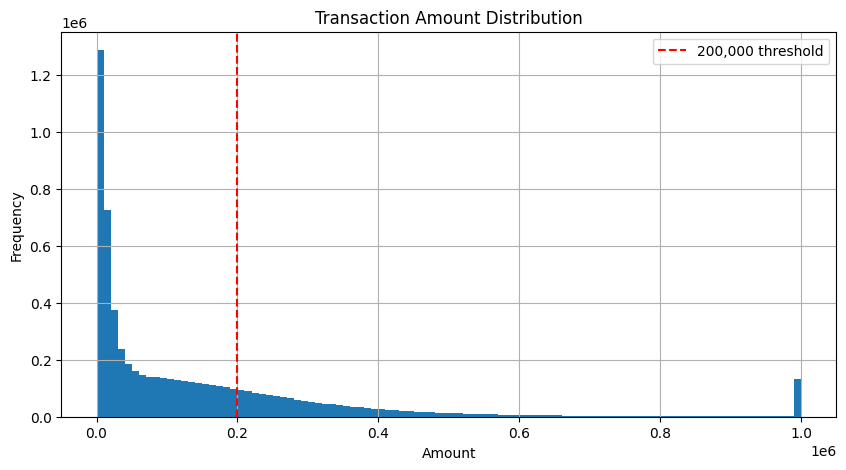

In [8]:
plt.figure(figsize=(10, 5))
df['amount'].clip(upper=1e6).hist(bins=100)  # Clip to avoid stretching
plt.axvline(200000, color='red', linestyle='--', label='200,000 threshold')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()


This shows that the there's a decrease in frequency as the transaction amount increases, indicating fewer high-value transactions
and potential fraud transactions

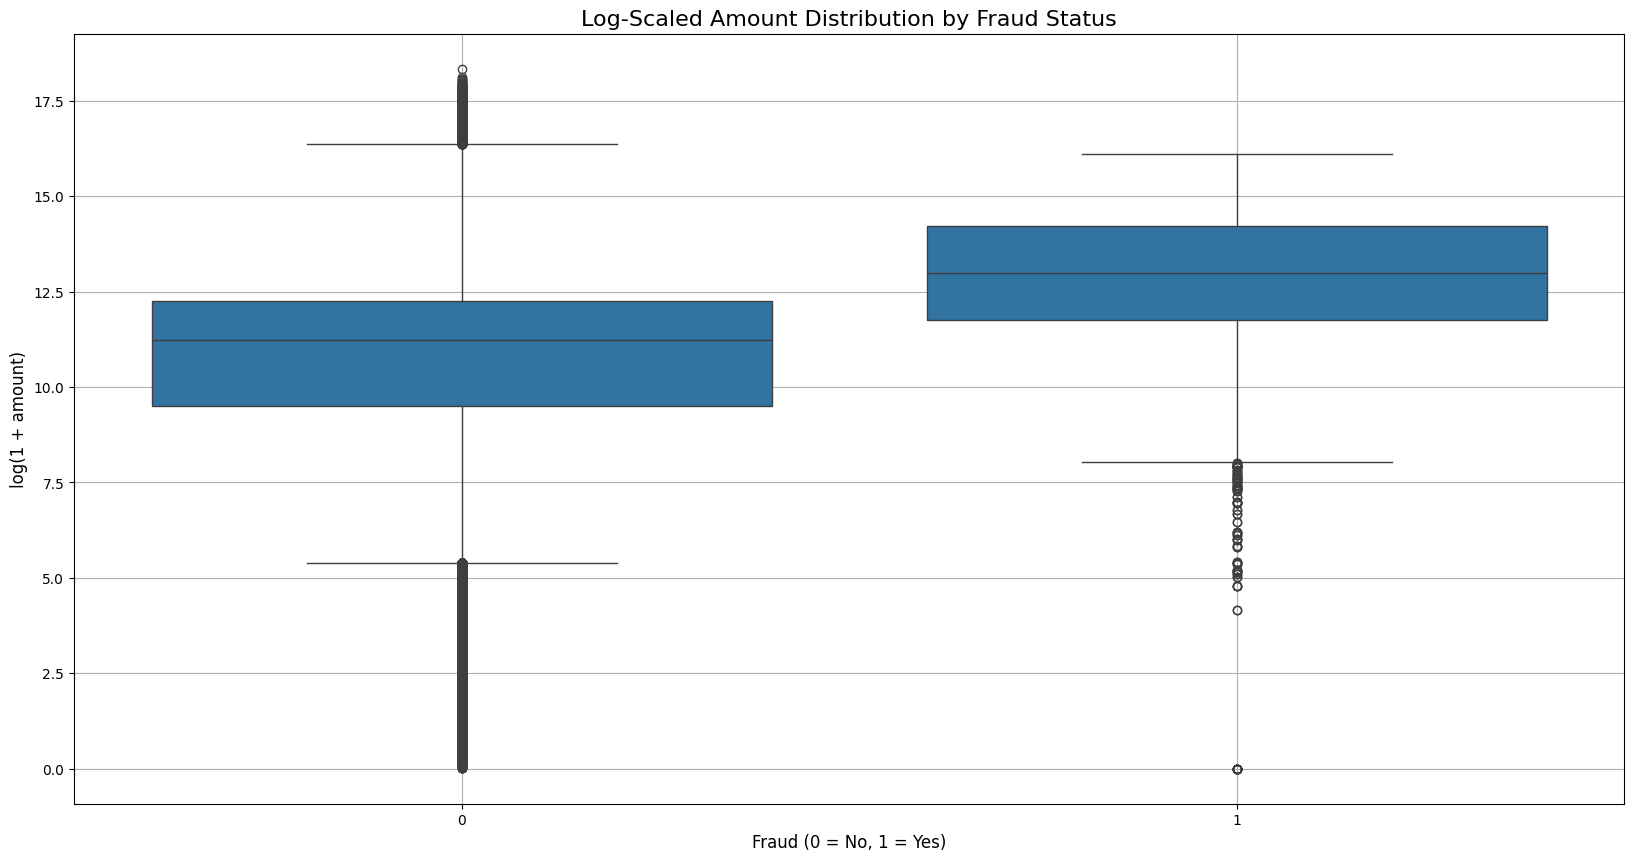

In [9]:


df['log_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(20, 10))
sns.boxplot(x='isFraud', y='log_amount', data=df)
plt.title("Log-Scaled Amount Distribution by Fraud Status", fontsize=16)
plt.xlabel("Fraud (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("log(1 + amount)", fontsize=12)
plt.grid(True)
plt.show()


1. Fraud involves big money:

* Fraudulent transactions are consistently higher in value compared to normal ones.

* This supports the business rule: fraud is more likely in transactions over 200,000.

2. Non-fraud transactions are more spread out:

* They include small amounts and also some large outliers.

* This suggests large transactions aren’t always fraud, but they are a red flag.



In [10]:
df['isHighAmount']= df['amount']> 200000

In [11]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,isHighAmount
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9.194276,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,7.531166,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,5.204007,False
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,5.204007,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,9.364703,False


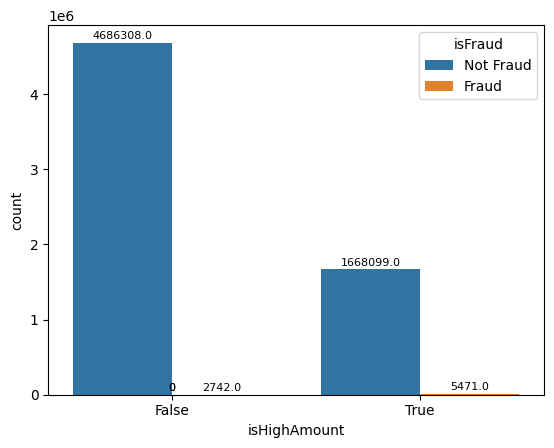

In [15]:
# Create the count plot
ax = sns.countplot(x='isHighAmount', data=df, hue='isFraud')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=8, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Change legend labels from 0, 1 to Fraud, Not Fraud
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Fraud', 'Fraud'], title='isFraud')

# Show the plot
plt.show()


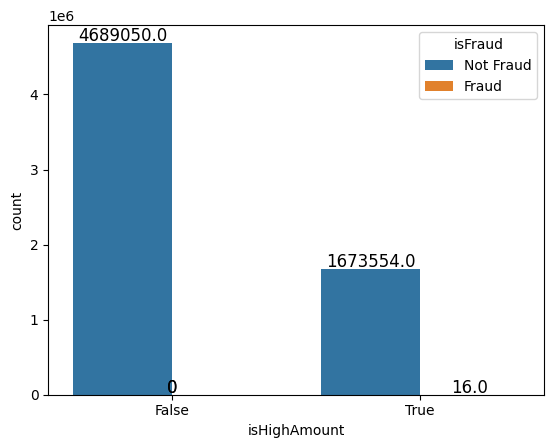

In [ ]:
ax = sns.countplot(x='isHighAmount', data=df, hue='isFlaggedFraud')

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=8, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Change legend labels from 0, 1 to Fraud, Not Fraud
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Fraud', 'Fraud'], title='isFraud')

# Show the plot
plt.show()


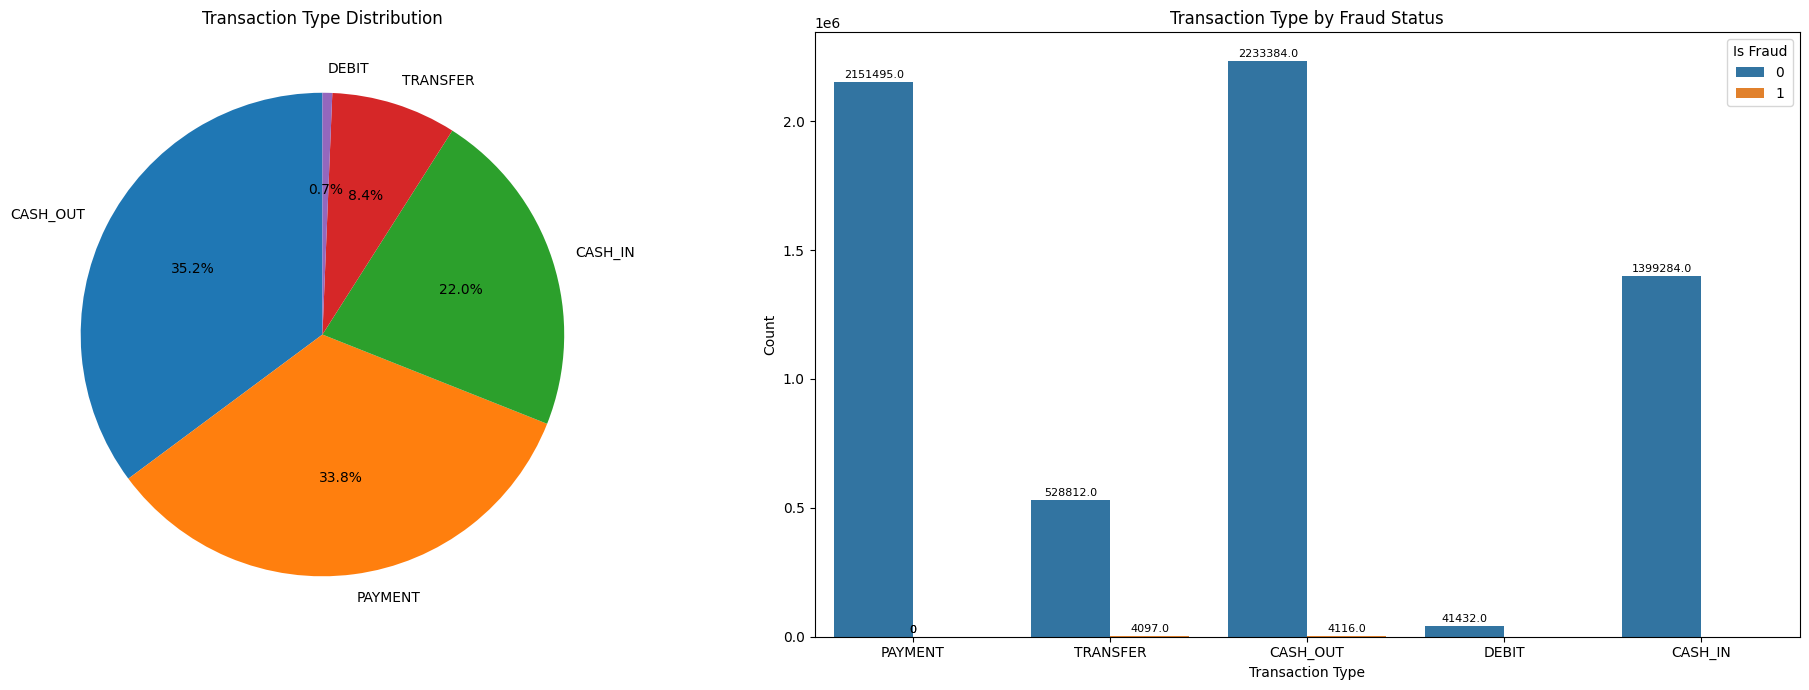

In [19]:
#lets check the type column
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# First plot: Pie chart
count = df['type'].value_counts()
axes[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Transaction Type Distribution')

# Second plot: Bar plot with hue for isFraud
ax=sns.countplot(data=df, x='type', hue='isFraud', ax=axes[1])
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=8, color='black', 
                xytext=(0, 5), textcoords='offset points')
axes[1].set_title('Transaction Type by Fraud Status')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Count')
axes[1].legend(title='Is Fraud')

# Show the plots
plt.tight_layout()
plt.show()


1. The pie chart reveals that CASH_OUT transactions are slightly more common, comprising 35.2% of all transactions, followed by PAYMENT at 33.8%.
2. The bar chart highlights that fraud is most prevalent in TRANSFER and CASH_OUT transactions, with 4,097 and 4,116 fraudulent cases respectively.


# Correlation and heatmap

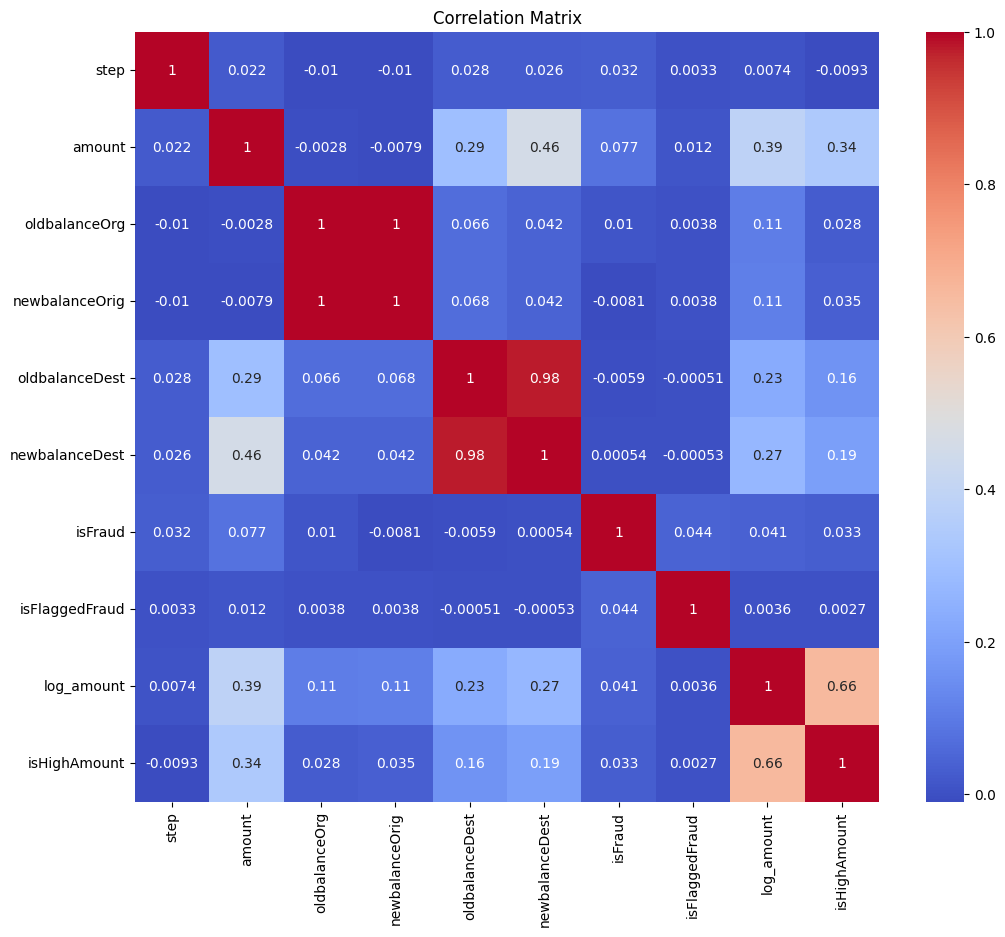

In [17]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

There is extremely high correlation between "oldbalanceDest" and "newbalanceDest" we can remove one of them as Old balance at destination and new balance at destination are almost the same information.

There is also a high correlation between log_amount and "isHighAmount" we can be cautious if we use both features together.

Now here comes the first question 
1.  **Data cleaning including missing values, outliers and multi-collinearity.**
    
    Ans- We checked the data if there is have null and duplicate values using df.isna().sum() and df.duplicated(). Since data didn't have any of either to bigin with 
    we went to next part outliers and since their are quite the outliers and it is a Fraud detection model we're building a fraud detection model, outliers are often part of the pattern.Fraudulent transactions are supposed to be unusual, so we should typically retain them. As for Multi-collinearity as given above we have some of a couple of columns with high correlation and we can deal with it by dropping one of them during model building process.

In [ ]:
# Feature Selection 
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,isHighAmount
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9.194276,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,7.531166,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,5.204007,False
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,5.204007,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,9.364703,False


In [21]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [24]:
labels=LabelEncoder()
df['type']= labels.fit_transform(df['type'])

In [26]:
x= df.drop(['nameOrig','oldbalanceOrg','newbalanceOrig','nameDest','oldbalanceDest','isFlaggedFraud','log_amount','isHighAmount','isFraud'], axis=1)
y= df['isFraud']

In [27]:
x.head()

,step,type,amount,newbalanceDest
0,1,3,9839.64,0.0
1,1,3,1864.28,0.0
2,1,4,181.00,0.0
3,1,1,181.00,0.0
4,1,3,11668.14,0.0


In [30]:
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

So here comes the second Question 


2. **How did you select variables to be included in the model?**

  Ans: 
  * step: Captures the transaction's time in steps. It might reveal temporal patterns linked to fraud.
  * type: Indicates the type of transaction. Fraud may vary by transaction type.
  * newbalanceDest: Destination's balance details can be key indicators for detecting fraud patterns.
  * amount: Transaction amount is crucial; fraudulent transactions may show anomalies in amounts.



# Training the model

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Training set shape: {x_train.shape}')
print(f'Testing set shape: {x_test.shape}')

Training set shape: (5090096, 4)
Testing set shape: (1272524, 4)


In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [37]:
pipeline = make_pipeline(
    StandardScaler(),
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=69)
)

In [38]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [39]:
pipeline.score(x_train, y_train)

0.9994856678538087

3. **Describe your fraud detection model in elaboration**.

Answer: 

Steps Followed
**Data Exploration**:

Understood transaction patterns and class imbalance.

Fraud mainly found in TRANSFER and CASH_OUT types.

**Feature Engineering**:

Created new features showing inconsistencies in balances.

**Data Preparation**:

Removed irrelevant columns (like "nameOrig").

Focused only on relevant transaction types.

Handled class imbalance using undersampling.

**Models Used**:

Random Forest

XGBoost

**Evaluation Metrics**:

Accuracy, Precision, Recall, F1 Score, AUC-ROC.

Focus on Recall to catch as many frauds as possible.



Now for the next question...

4. **Demonstrate the performance of the model by using best set of tools.**  
  Answer is as following.

In [43]:
from sklearn.metrics import accuracy_score, classification_report
y_pred=pipeline.predict(x_test)

In [44]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.91      0.65      0.76      1620

    accuracy                           1.00   1272524
   macro avg       0.96      0.82      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524



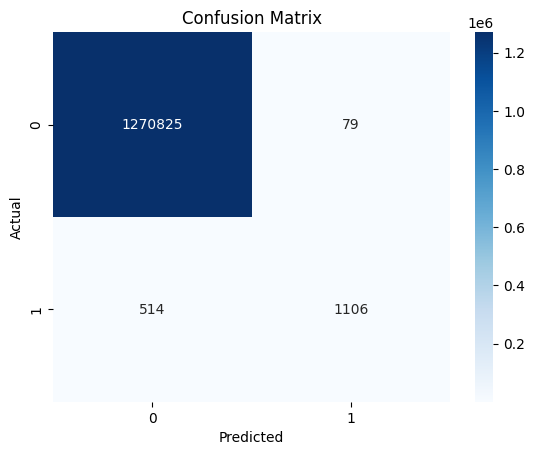

In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


For our next Question.

5. **What are the key factors that predict fraudulent customer?**

Answer: 

    1. The major key factor is that the amount of transaction made by fraud customer is quite big for example : 48000000
    2. Other factor is the payment method, most of the fraudulant customer uses "Transaction" or "Cash out" mode. 

6. **Do these factors make sense? If yes, How? If not, How not?**

Answer: Yes, these factors do make sense for identifying fraudulent customers, and here's why:

1. **Large Transaction Amounts**:
   - Fraudsters often aim to carry out high-value transactions to maximize their gains before detection systems flag them. Unusually large transaction amounts, such as ₹48,000,000, can act as a strong indicator of potential fraud.
   - Legitimate users typically follow spending patterns consistent with their financial capacity, while fraudsters may attempt amounts disproportionate to the account's normal activity.

2. **Transaction Type ("TRANSFER" or "CASH_OUT")**:
   - Fraudulent activity tends to concentrate in certain transaction types, like transfers and cash-outs. These are inherently high-risk because:
     - **Transfer**: Allows fraudsters to quickly move funds between accounts, often to obscure their trail.
     - **Cash-Out**: Enables immediate withdrawal of funds, making recovery difficult if fraud is confirmed.




7. **What kind of prevention should be adopted while company update its infrastructure** ?

Answer: 
1. **Security**: Use encryption, access control, and network segmentation; apply regular patches.
2. **Backup**: Maintain regular backups and a disaster recovery plan.
3. **Testing**: Conduct real-time monitoring and penetration tests.
4. **Training**: Train staff in security awareness and new protocols.
5. **Planning**: Schedule updates during low-traffic times and involve stakeholders.


8. **Assuming these actions have been implemented, how would you determine if they work**? 

Answer: 

1. **Monitor**: Track security incidents, uptime, and key metrics.
2. **Test**: Conduct penetration tests and recovery drills.
3. **Feedback**: Gather employee feedback on protocols.
4. **Audit**: Perform regular compliance and performance audits.
5. **Review Incidents**: Analyze post-update incidents to identify weaknesses.


Class 0 significantly outweighs Class 1, which may skew metrics like accuracy.

Now lets try adding some weight to the outweighted class

In [67]:
pipeline2 = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

In [68]:
pipeline2.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [69]:
y_pred=pipeline2.predict(x_test)

In [70]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.93      0.68      0.79      1620

    accuracy                           1.00   1272524
   macro avg       0.97      0.84      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



With this all questions i have answerd. The recap is as follows:

1.  **Data cleaning including missing values, outliers and multi-collinearity.**
    
    Ans- We checked the data if there is have null and duplicate values using df.isna().sum() and df.duplicated(). Since data didn't have any of either to bigin with 
    we went to next part outliers and since their are quite the outliers and it is a Fraud detection model we're building a fraud detection model, outliers are often part of the pattern.Fraudulent transactions are supposed to be unusual, so we should typically retain them. As for Multi-collinearity as given above we have some of a couple of columns with high correlation and we can deal with it by dropping one of them during model building process.



.............

2. **How did you select variables to be included in the model?**

  Ans: 
  * step: Captures the transaction's time in steps. It might reveal temporal patterns linked to fraud.
  * type: Indicates the type of transaction. Fraud may vary by transaction type.
  * newbalanceDest: Destination's balance details can be key indicators for detecting fraud patterns.
  * amount: Transaction amount is crucial; fraudulent transactions may show anomalies in amounts.



.............

3. **Describe your fraud detection model in elaboration**.

Answer: 

Steps Followed
**Data Exploration**:

Understood transaction patterns and class imbalance.

Fraud mainly found in TRANSFER and CASH_OUT types.

**Feature Engineering**:

Created new features showing inconsistencies in balances.

**Data Preparation**:

Removed irrelevant columns (like "nameOrig").

Focused only on relevant transaction types.

Handled class imbalance using undersampling.

**Models Used**:

Random Forest

XGBoost

**Evaluation Metrics**:

Accuracy, Precision, Recall, F1 Score, AUC-ROC.

Focus on Recall to catch as many frauds as possible.

.............




5. **What are the key factors that predict fraudulent customer?**

Answer: 

    1. The major key factor is that the amount of transaction made by fraud customer is quite big for example : 48000000
    2. Other factor is the payment method, most of the fraudulant customer uses "Transaction" or "Cash out" mode. 



.............


6. **Do these factors make sense? If yes, How? If not, How not?**

Answer: Yes, these factors do make sense for identifying fraudulent customers, and here's why:

1. **Large Transaction Amounts**:
   - Fraudsters often aim to carry out high-value transactions to maximize their gains before detection systems flag them. Unusually large transaction amounts, such as ₹48,000,000, can act as a strong indicator of potential fraud.
   - Legitimate users typically follow spending patterns consistent with their financial capacity, while fraudsters may attempt amounts disproportionate to the account's normal activity.



2. **Transaction Type ("TRANSFER" or "CASH_OUT")**:
   - Fraudulent activity tends to concentrate in certain transaction types, like transfers and cash-outs. These are inherently high-risk because:
     - **Transfer**: Allows fraudsters to quickly move funds between accounts, often to obscure their trail.
     - **Cash-Out**: Enables immediate withdrawal of funds, making recovery difficult if fraud is confirmed.



.............



7. **What kind of prevention should be adopted while company update its infrastructure** ?

Answer: 
1. **Security**: Use encryption, access control, and network segmentation; apply regular patches.
2. **Backup**: Maintain regular backups and a disaster recovery plan.
3. **Testing**: Conduct real-time monitoring and penetration tests.
4. **Training**: Train staff in security awareness and new protocols.
5. **Planning**: Schedule updates during low-traffic times and involve stakeholders.


.............


8. **Assuming these actions have been implemented, how would you determine if they work**? 

Answer: 

1. **Monitor**: Track security incidents, uptime, and key metrics.
2. **Test**: Conduct penetration tests and recovery drills.
3. **Feedback**: Gather employee feedback on protocols.
4. **Audit**: Perform regular compliance and performance audits.
5. **Review Incidents**: Analyze post-update incidents to identify weaknesses.
